In [1]:
#Imports

import os
import numpy as np
import pickle
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

print("TensorFlow:", tf.__version__)
print("All evaluation libraries imported.")

I0000 00:00:1790608350.847805  205265 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
All evaluation libraries imported.


In [2]:
#Config and load test data

OUTPUT_DIR = "/home/user/22059240/FYP/processed"
MODELS_DIR = "/home/user/22059240/FYP/models"
LOGS_DIR   = "/home/user/22059240/FYP/logs"

WINDOW_SIZE  = 30
FEATURE_DIM  = 166
RANDOM_SEED  = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

X_test = np.load(os.path.join(OUTPUT_DIR, "X_test.npy"))
y_test = np.load(os.path.join(OUTPUT_DIR, "y_test.npy"))

print("Test set loaded.")
print(f"  X_test           : {X_test.shape}")
print(f"  y_test           : {y_test.shape}")
print(f"  Fall samples     : {y_test.sum()}")
print(f"  Non-fall samples : {(y_test == 0).sum()}")

Test set loaded.
  X_test           : (243, 30, 166)
  y_test           : (243,)
  Fall samples     : 53
  Non-fall samples : 190


In [3]:
#Load saved models 

model_names = [
    "simple_lstm",
    "stacked_lstm",
    "bilstm",
    "gru",
    "cnn_lstm"
]

display_names = {
    "simple_lstm"  : "Simple LSTM",
    "stacked_lstm" : "Stacked LSTM",
    "bilstm"       : "BiLSTM",
    "gru"          : "GRU",
    "cnn_lstm"     : "CNN-LSTM"
}

loaded_models = {}
for name in model_names:
    path = os.path.join(MODELS_DIR, f"{name}_final.keras")
    loaded_models[name] = load_model(path)
    print(f"Loaded: {display_names[name]}")

print("\nAll models loaded successfully.")

W0000 00:00:1790608463.601559  208018 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1790608463.696627  205265 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Loaded: Simple LSTM
Loaded: Stacked LSTM
Loaded: BiLSTM
Loaded: GRU
Loaded: CNN-LSTM

All models loaded successfully.


In [4]:
# Define evaluation functions 

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a trained model on the test set.
    Reports accuracy, precision, recall, F1-score,
    confusion matrix and mean inference latency.
    """
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred      = (y_pred_prob >= 0.5).astype(int).flatten()

    acc  = accuracy_score(y_test,  y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test,    y_pred, zero_division=0)
    f1   = f1_score(y_test,        y_pred, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)

    # Inference latency — mean over 100 single-window predictions
    sample_window = X_test[:1]
    latencies = []
    for _ in range(100):
        t0 = time.time()
        _ = model.predict(sample_window, verbose=0)
        latencies.append((time.time() - t0) * 1000)

    mean_latency = np.mean(latencies)
    real_time_ok = mean_latency < 33.0

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  Latency   : {mean_latency:.2f} ms "
          f"({'✓ Real-time' if real_time_ok else '✗ Too slow'})")
    print(f"\n  Classification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=["Non-fall", "Fall"]
    ))

    return {
        "model"      : model_name,
        "accuracy"   : acc,
        "precision"  : prec,
        "recall"     : rec,
        "f1"         : f1,
        "latency_ms" : mean_latency,
        "cm"         : cm,
        "y_pred"     : y_pred
    }

print("Evaluate function defined.")

Evaluate function defined.


In [5]:
# Run evaluation on all models 

results = []

for name in model_names:
    res = evaluate_model(
        loaded_models[name],
        X_test,
        y_test,
        display_names[name]
    )
    results.append(res)


  Simple LSTM
  Accuracy  : 0.8272
  Precision : 0.5696
  Recall    : 0.8491
  F1-Score  : 0.6818
  Latency   : 41.73 ms (✗ Too slow)

  Classification Report:
              precision    recall  f1-score   support

    Non-fall       0.95      0.82      0.88       190
        Fall       0.57      0.85      0.68        53

    accuracy                           0.83       243
   macro avg       0.76      0.84      0.78       243
weighted avg       0.87      0.83      0.84       243


  Stacked LSTM
  Accuracy  : 0.8436
  Precision : 0.6000
  Recall    : 0.8491
  F1-Score  : 0.7031
  Latency   : 41.56 ms (✗ Too slow)

  Classification Report:
              precision    recall  f1-score   support

    Non-fall       0.95      0.84      0.89       190
        Fall       0.60      0.85      0.70        53

    accuracy                           0.84       243
   macro avg       0.78      0.85      0.80       243
weighted avg       0.88      0.84      0.85       243


  BiLSTM
  Accuracy  :

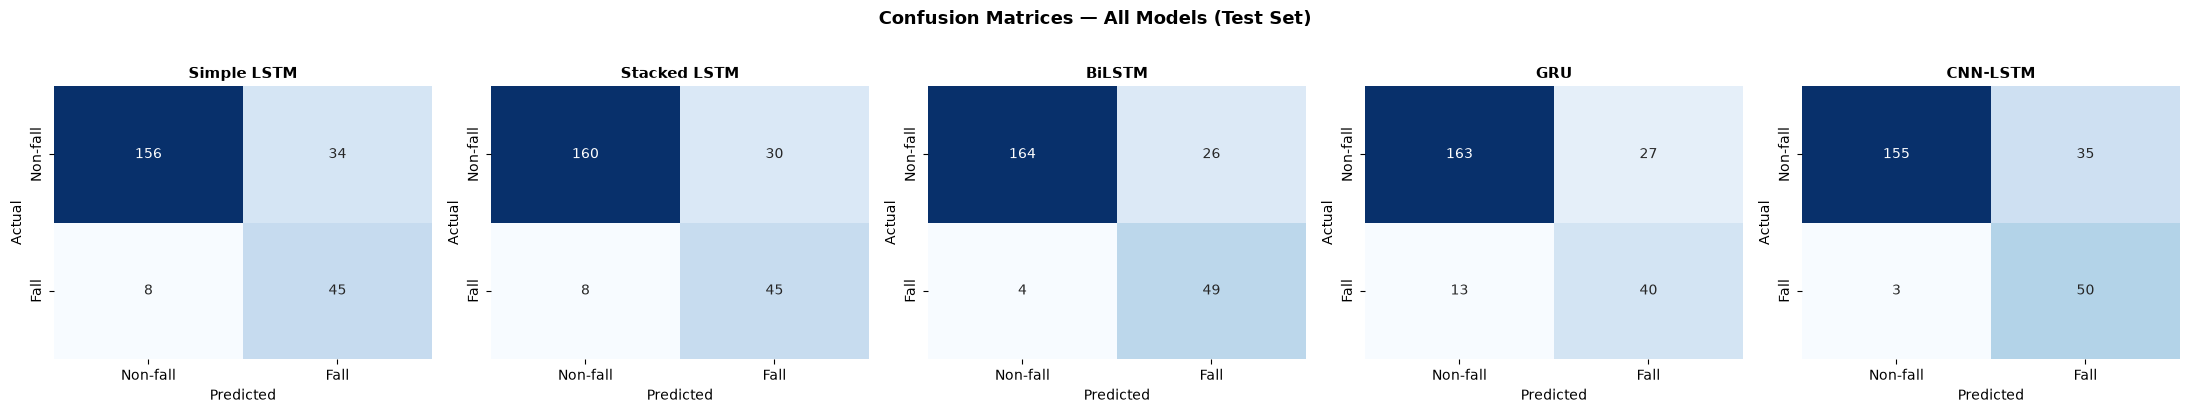

Confusion matrices saved.


In [6]:
# Plot confusion matrix 

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, res in zip(axes, results):
    sns.heatmap(
        res["cm"],
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=["Non-fall", "Fall"],
        yticklabels=["Non-fall", "Fall"],
        ax=ax,
        cbar=False
    )
    ax.set_title(res["model"], fontsize=11, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle(
    "Confusion Matrices — All Models (Test Set)",
    fontsize=13,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.savefig(
    os.path.join(LOGS_DIR, "confusion_matrices_all_models.png"),
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Confusion matrices saved.")

In [7]:
# Comparison summary table 

summary_df = pd.DataFrame([{
    "Model"        : r["model"],
    "Accuracy"     : f"{r['accuracy']:.4f}",
    "Precision"    : f"{r['precision']:.4f}",
    "Recall"       : f"{r['recall']:.4f}",
    "F1-Score"     : f"{r['f1']:.4f}",
    "Latency (ms)" : f"{r['latency_ms']:.2f}",
    "Real-time"    : "✓" if r['latency_ms'] < 33.0 else "✗"
} for r in results])

print("\n" + "=" * 65)
print("MODEL COMPARISON SUMMARY — TEST SET")
print("=" * 65)
print(summary_df.to_string(index=False))
print("=" * 65)

summary_df.to_csv(
    os.path.join(LOGS_DIR, "model_comparison_summary.csv"),
    index=False
)
print("Summary saved to logs/model_comparison_summary.csv")


MODEL COMPARISON SUMMARY — TEST SET
       Model Accuracy Precision Recall F1-Score Latency (ms) Real-time
 Simple LSTM   0.8272    0.5696 0.8491   0.6818        41.73         ✗
Stacked LSTM   0.8436    0.6000 0.8491   0.7031        41.56         ✗
      BiLSTM   0.8765    0.6533 0.9245   0.7656        41.89         ✗
         GRU   0.8354    0.5970 0.7547   0.6667        41.02         ✗
    CNN-LSTM   0.8436    0.5882 0.9434   0.7246        40.83         ✗
Summary saved to logs/model_comparison_summary.csv


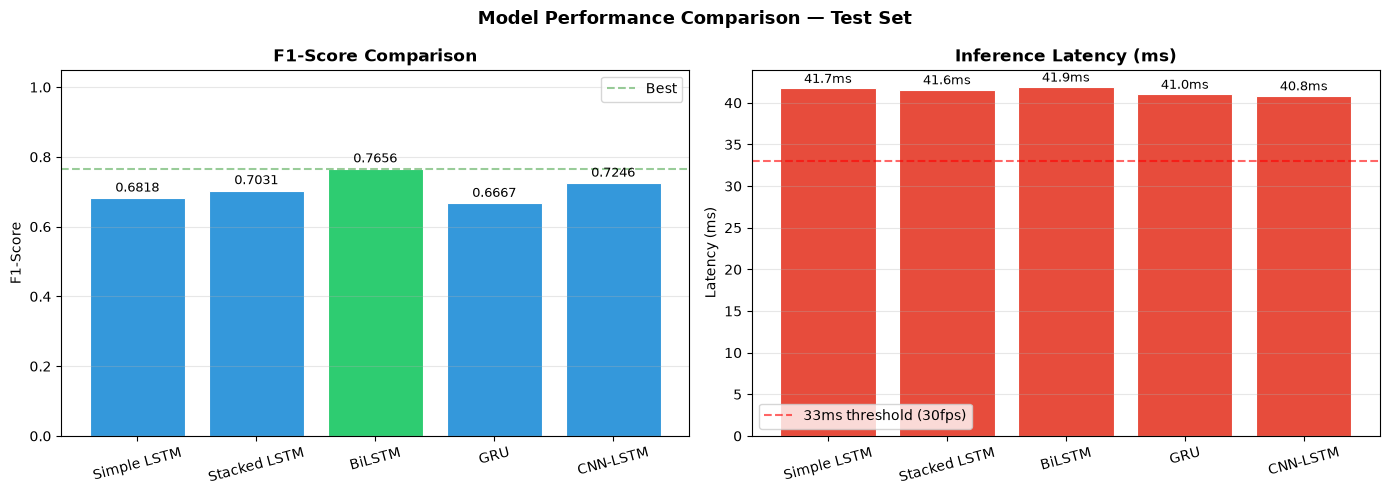

Comparison charts saved.


In [8]:
#F1-score and latency bar chart 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names_list = [r["model"]      for r in results]
f1_scores  = [r["f1"]         for r in results]
latencies  = [r["latency_ms"] for r in results]

colours_f1 = [
    "#2ecc71" if f == max(f1_scores) else "#3498db"
    for f in f1_scores
]
colours_lt = [
    "#e74c3c" if l > 33 else "#2ecc71"
    for l in latencies
]

# F1-score bar chart
bars1 = axes[0].bar(
    names_list, f1_scores,
    color=colours_f1,
    edgecolor='white',
    linewidth=0.8
)
axes[0].set_title("F1-Score Comparison", fontweight='bold', fontsize=12)
axes[0].set_ylabel("F1-Score")
axes[0].set_ylim(0, 1.05)
axes[0].axhline(
    y=max(f1_scores),
    color='green',
    linestyle='--',
    alpha=0.4,
    label='Best'
)
for bar, val in zip(bars1, f1_scores):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.4f}",
        ha='center', va='bottom', fontsize=9
    )
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

# Latency bar chart
bars2 = axes[1].bar(
    names_list, latencies,
    color=colours_lt,
    edgecolor='white',
    linewidth=0.8
)
axes[1].set_title("Inference Latency (ms)", fontweight='bold', fontsize=12)
axes[1].set_ylabel("Latency (ms)")
axes[1].axhline(
    y=33,
    color='red',
    linestyle='--',
    alpha=0.6,
    label='33ms threshold (30fps)'
)
for bar, val in zip(bars2, latencies):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val:.1f}ms",
        ha='center', va='bottom', fontsize=9
    )
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

plt.suptitle(
    "Model Performance Comparison — Test Set",
    fontsize=13,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    os.path.join(LOGS_DIR, "model_comparison_charts.png"),
    dpi=150
)
plt.show()
print("Comparison charts saved.")

In [9]:
# Select and save best model

best_result = max(results, key=lambda r: r["f1"])

print(f"\nBest model by F1-score : {best_result['model']}")
print(f"  F1-Score  : {best_result['f1']:.4f}")
print(f"  Recall    : {best_result['recall']:.4f}")
print(f"  Precision : {best_result['precision']:.4f}")
print(f"  Accuracy  : {best_result['accuracy']:.4f}")
print(f"  Latency   : {best_result['latency_ms']:.2f} ms")

# Map display name back to key
name_to_key = {v: k for k, v in display_names.items()}
best_key    = name_to_key[best_result["model"]]
best_model  = loaded_models[best_key]

# Save best model
best_model_path = os.path.join(MODELS_DIR, "best_model_final.keras")
best_model.save(best_model_path)
print(f"\nBest model saved to: {best_model_path}")

# Save best model name for reference in realtime_demo.ipynb
with open(os.path.join(MODELS_DIR, "best_model_name.txt"), "w") as f:
    f.write(best_result["model"])

print(f"Best model name saved to: {MODELS_DIR}/best_model_name.txt")


Best model by F1-score : BiLSTM
  F1-Score  : 0.7656
  Recall    : 0.9245
  Precision : 0.6533
  Accuracy  : 0.8765
  Latency   : 41.89 ms

Best model saved to: /home/user/22059240/FYP/models/best_model_final.keras
Best model name saved to: /home/user/22059240/FYP/models/best_model_name.txt


In [11]:
# Per class error analysis 

print(f"{'Model':<15} {'TP':>6} {'TN':>6} {'FP':>6} {'FN':>6} "
      f"{'FP Rate':>9} {'FN Rate':>9}")
print("-" * 65)

for r in results:
    cm           = r["cm"]
    tn, fp, fn, tp = cm.ravel()
    fp_rate      = fp / (fp + tn) if (fp + tn) > 0 else 0
    fn_rate      = fn / (fn + tp) if (fn + tp) > 0 else 0

    print(f"{r['model']:<15} {tp:>6} {tn:>6} {fp:>6} {fn:>6} "
          f"{fp_rate:>9.4f} {fn_rate:>9.4f}")

print("-" * 65)
print("FP Rate = False alarm rate         (lower is better)")
print("FN Rate = Missed detection rate    (lower is better — safety critical)")

Model               TP     TN     FP     FN   FP Rate   FN Rate
-----------------------------------------------------------------
Simple LSTM         45    156     34      8    0.1789    0.1509
Stacked LSTM        45    160     30      8    0.1579    0.1509
BiLSTM              49    164     26      4    0.1368    0.0755
GRU                 40    163     27     13    0.1421    0.2453
CNN-LSTM            50    155     35      3    0.1842    0.0566
-----------------------------------------------------------------
FP Rate = False alarm rate         (lower is better)
FN Rate = Missed detection rate    (lower is better — safety critical)


In [12]:
#Summary

best    = max(results, key=lambda r: r["f1"])
ranked  = sorted(results, key=lambda r: r["f1"], reverse=True)
runnerup = ranked[1]

print("=" * 55)
print("FINAL EVALUATION SUMMARY")
print("=" * 55)
print(f"\nBest model    : {best['model']}")
print(f"  F1-Score    : {best['f1']:.4f}")
print(f"  Recall      : {best['recall']:.4f}  ← safety priority")
print(f"  Precision   : {best['precision']:.4f}")
print(f"  Accuracy    : {best['accuracy']:.4f}")
print(f"  Latency     : {best['latency_ms']:.2f} ms "
      f"({'✓ Suitable for real-time' if best['latency_ms'] < 33 else '✗ Exceeds 33ms'})")
print(f"\nRunner-up     : {runnerup['model']} "
      f"(F1: {runnerup['f1']:.4f})")
print(f"\nSelected model will be used in realtime_demo.ipynb")
print("=" * 55)

FINAL EVALUATION SUMMARY

Best model    : BiLSTM
  F1-Score    : 0.7656
  Recall      : 0.9245  ← safety priority
  Precision   : 0.6533
  Accuracy    : 0.8765
  Latency     : 41.89 ms (✗ Exceeds 33ms)

Runner-up     : CNN-LSTM (F1: 0.7246)

Selected model will be used in realtime_demo.ipynb
